# 2D Dam Break Simulation with SPH

## Collapse of a Fluid Column under Gravity

This tutorial simulates a classic **2D dam break**: a dense fluid column confined to the left quarter of a closed box is released at $t=0$. Gravity pulls the fluid downward and the pressure gradient drives a horizontal spreading wave. The SPH method naturally handles the large interface deformation and free-surface dynamics.

### Physical Setup

The domain is a $1 \times 1$ box with **reflective walls** on all sides. At $t = 0$ the fluid occupies the region $x \in [0, L/4]$ at density $\rho_\text{high}$; the rest of the box is effectively empty (markers with negligible weight are removed). As the fluid evolves:

1. The column collapses under downward gravity $g_y$.
2. The pressure gradient ($\propto c_s^2 \nabla\rho$ in the isothermal model) drives a shock-like spreading wave.
3. Viscosity damps small-scale velocity fluctuations and stabilises the SPH.
4. Reflections off the walls cause the fluid to slosh and eventually reach a hydrostatic equilibrium with density concentrated at the bottom.

### SPH parameters for compressible free-surface flows

The isothermal equation of state $p = \kappa \rho$ is used with a **weak compressibility** coefficient $\kappa = c_s^2 \ll 1$. This keeps the flow subsonic (Mach number $\text{Ma} = U_\text{max}/c_s \ll 1$) while allowing large density variations — the *Weakly Compressible SPH* (WCSPH) regime.

Markers with very small weights (corresponding to the near-vacuum region) are removed by the `reject_weights` option before the simulation starts.

### What to expect

- The dense column hits the right wall, runs up it, and splashes back.
- Multiple reflections produce complex sloshing dynamics.
- At late times ($t \gtrsim 2$) the fluid settles near the bottom, forming a stable layer.
- As a qualitative verification we check that **no markers escape the closed box** throughout the simulation.

In [1]:
import logging
import os
import shutil

import numpy as np
import matplotlib.pyplot as plt

from struphy import (
    BoundaryParameters,
    EnvironmentOptions,
    KernelDensityPlot,
    LoadingParameters,
    SavingParameters,
    Simulation,
    SortingParameters,
    Time,
    WeightsParameters,
    domains,
    equils,
)
from struphy.models import ViscousEulerSPH
from struphy.ode.utils import ButcherTableau

logger = logging.getLogger("struphy")

### Physical and Numerical Parameters

The free-fall time from height $H/2$ is $\sqrt{2(H/2)/g_y} \approx 0.32$, so $T_\text{end} = 3$ covers roughly 9 free-fall times. The sound speed $c_s = \sqrt{\kappa} \approx 0.45$, giving Mach number $\text{Ma} = \sqrt{2 g_y H/2}/c_s \approx 0.71$ — weakly supersonic, which is acceptable for WCSPH with small $\kappa$.

In [2]:
# Physical parameters
kappa  = 0.2    # isothermal coefficient (= c_s^2); weak compressibility
mu     = 0.05   # dynamic viscosity (small, for stability)
g_y    = 10.0   # gravitational acceleration (downward = -y direction)
r1     = 1.0    # domain width  (x)
r2     = 1.0    # domain height (y)
n_high = 0.1    # initial density of the fluid column

# Derived
c_s     = kappa**0.5
U_max   = (2.0 * g_y * r2 / 2.0)**0.5   # rough free-fall velocity scale
Ma      = U_max / c_s

# Numerical parameters
nx       = 8    # boxes per spatial dimension
ppb      = 32   # particles per box
plot_pts = 21   # KDE evaluation points per dimension

# Time stepping: CFL limit ~ h/c_s = (r1/nx)/c_s
dt   = 0.02
Tend = 3.0

print(f"Sound speed:      c_s  = {c_s:.3f}")
print(f"Max velocity est: U_max = {U_max:.3f}  (Mach = {Ma:.2f})")
print(f"Fluid density:    n_high = {n_high}  (vacuum elsewhere)")
print(f"Time stepping:    dt={dt}, Tend={Tend}, {int(Tend/dt)} steps")
print(f"Total particles:  ~{ppb * nx * nx // 4} (left quarter of domain)")

Sound speed:      c_s  = 0.447
Max velocity est: U_max = 3.162  (Mach = 7.07)
Fluid density:    n_high = 0.1  (vacuum elsewhere)
Time stepping:    dt=0.02, Tend=3.0, 150 steps
Total particles:  ~512 (left quarter of domain)


### Model Setup

All three physical effects are active: pressure (`with_p=True`), viscosity (`with_viscosity=True`). The 2D Gaussian kernel is used. Gravity enters as a downward vector `(0, -g_y, 0)` in the pressure propagator.

In [3]:
model = ViscousEulerSPH(with_B0=False, with_p=True, with_viscosity=True)

butcher = ButcherTableau(algo="forward_euler")
model.propagators.push_eta.options     = model.propagators.push_eta.Options(butcher=butcher)
model.propagators.push_sph_p.options   = model.propagators.push_sph_p.Options(
    kernel_type="gaussian_2d",
    gravity=(0.0, -g_y, 0.0),   # downward gravity
    kappa=kappa,
)
model.propagators.push_viscous.options = model.propagators.push_viscous.Options(
    kernel_type="gaussian_2d",
    mu=mu,
)

print("ViscousEulerSPH configured (pressure + viscosity + gravity).")
print(f"  kappa={kappa}, mu={mu}, g_y={g_y} (downward)")

ViscousEulerSPH configured (pressure + viscosity + gravity).
  kappa=0.2, mu=0.05, g_y=10.0 (downward)


### Domain, Boundary Conditions and Diagnostics

The box has **reflective walls** on all sides (`bc="reflect"`) with SPH mirror ghost particles (`bc_sph="mirror"`). The `reject_weights` option removes near-vacuum markers (those with weight below the threshold) so that only the dense left-column particles are simulated.

The `n_markers=1.0` option in `SavingParameters` saves every marker orbit at each time step, enabling post-hoc visualisation of particle trajectories.

In [4]:
domain = domains.Cuboid(r1=r1, r2=r2)

loading_params  = LoadingParameters(ppb=ppb, loading="tesselation")
weights_params  = WeightsParameters(reject_weights=True, threshold=1e-6)
boundary_params = BoundaryParameters(
    bc    =("reflect", "reflect",  "periodic"),
    bc_sph=("mirror",  "mirror",   "periodic"),
)
sorting_params = SortingParameters(
    boxes_per_dim=(nx, nx, 1),
    dims_mask=(True, True, False),
)

kd_plot = KernelDensityPlot(pts_e1=plot_pts, pts_e2=plot_pts, pts_e3=1)
saving_params = SavingParameters(
    n_markers=1.0,              # save all marker positions every step
    kernel_density_plots=(kd_plot,),
)

model.euler_fluid.set_markers(
    loading_params=loading_params,
    weights_params=weights_params,
    boundary_params=boundary_params,
    sorting_params=sorting_params,
    saving_params=saving_params,
    bufsize=2,
)

print(f"2D closed box [{r1}×{r2}], reflective walls on all sides")
print("Vacuum markers (weight < 1e-6) removed before simulation")

2D closed box [1.0×1.0], reflective walls on all sides
Vacuum markers (weight < 1e-6) removed before simulation


### Initial Conditions

The `step_function_xy` density profile places $\rho = \rho_\text{high}$ where $x < L/4$ and $y < H$, and near-vacuum ($\sim 10^{-8}$) elsewhere. The near-vacuum markers are then removed by the `reject_weights` filter, leaving only the dense left-column particles.

We colour each marker by its initial $x$-position (normalised to $[0, 1]$ within the column) to track how the fluid mixes during the dam break.

In [5]:
background = equils.ConstantVelocity(
    density_profile="step_function_xy",
    n=n_high,
    upper_x=r1 / 4,   # dense column: x < r1/4
    upper_y=r2,
)
model.euler_fluid.var.add_background(background)

print(f"Initial condition: dense column (n={n_high}) for x < {r1/4}")
print("Near-vacuum markers (x > r1/4) will be removed by reject_weights")

Initial condition: dense column (n=0.1) for x < 0.25
Near-vacuum markers (x > r1/4) will be removed by reject_weights


### Simulation Setup and Execution

In [6]:
test_folder = os.path.join(os.getcwd(), "struphy_verification_tests")
out_folders = os.path.join(test_folder, "ViscousEulerSPH")
env = EnvironmentOptions(out_folders=out_folders, sim_folder="dam_break")

time_opts = Time(dt=dt, Tend=Tend, split_algo="Strang")

sim = Simulation(
    model=model,
    env=env,
    time_opts=time_opts,
    domain=domain,
    grid=None,
    derham_opts=None,
)

print(f"Running 2D dam break: dt={dt}, Tend={Tend}")
sim.run()
print("Simulation complete.")

sim.pproc()
print("Post-processing complete.")


Starting run for model ViscousEulerSPH ...


Running 2D dam break: dt=0.02, Tend=3.0


Time stepping:   0%|          | 0/150 [00:00<?, ?step/s]

Time stepping:   1%|          | 1/150 [00:00<00:16,  9.08step/s]

Time stepping:   1%|▏         | 2/150 [00:00<00:16,  9.24step/s]

...

 74%|███████▎  | 111/151 [00:00<00:00, 364.48it/s]

 98%|█████████▊| 148/151 [00:00<00:00, 364.39it/s]

100%|██████████| 151/151 [00:00<00:00, 363.66it/s]


Evaluation of sph density for euler_fluid


Post-processing complete.


### Load Diagnostics

In [7]:
sim.load_plotting_data()

# KDE density field: shape (Nt+1, pts_e1, pts_e2, 1)
ee1, ee2, ee3 = sim.n_sph.euler_fluid.view_0.grid_n_sph
n_sph = sim.n_sph.euler_fluid.view_0.n_sph

# Marker orbits: shape (Nt_orb, n_markers, n_attrs)
# attrs for vdim=2: [x, y, z, v1, v2, w, diag, id]
orbits = np.asarray(sim.orbits.euler_fluid)

Nt      = int(Tend / dt)
times   = np.linspace(0.0, Tend, Nt + 1)
Nt_orb  = orbits.shape[0]
t_orbit = np.linspace(0.0, Tend, Nt_orb)

X = np.asarray(ee1)[:, :, 0] * r1   # physical x, shape (pts_e1, pts_e2)
Y = np.asarray(ee2)[:, :, 0] * r2   # physical y
n_arr = np.asarray(n_sph)            # (Nt+1, pts_e1, pts_e2, 1)

# Colour each marker by its initial x position within the column
x_init = orbits[0, :, 0]
c_val  = x_init / (r1 / 4.0)        # 0 = left wall, 1 = dam face

print(f"KDE field shape:   {n_arr.shape}")
print(f"Marker orbits:     {orbits.shape}  [{Nt_orb} snapshots, {orbits.shape[1]} markers]")


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/struphy_verification_tests/ViscousEulerSPH/dam_break/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(151,)


...

    euler_fluid, shape = (151, 512, 8)
        Number of time points: 151
        Number of particles:   512
        Number of attributes:  8



self.f:


self.n_sph:


    euler_fluid
        view_0



KDE field shape:   (151, 21, 21, 1)
Marker orbits:     (151, 512, 8)  [151 snapshots, 512 markers]


### Visualisation: Density Field Snapshots

Twelve equally spaced snapshots show the KDE density field (colour map) overlaid with marker positions (coloured by initial $x$). The colour gradient from blue (left wall) to red (dam face) reveals how the fluid column mixes as it spreads across the domain.

/tmp/ipykernel_11115/933893305.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


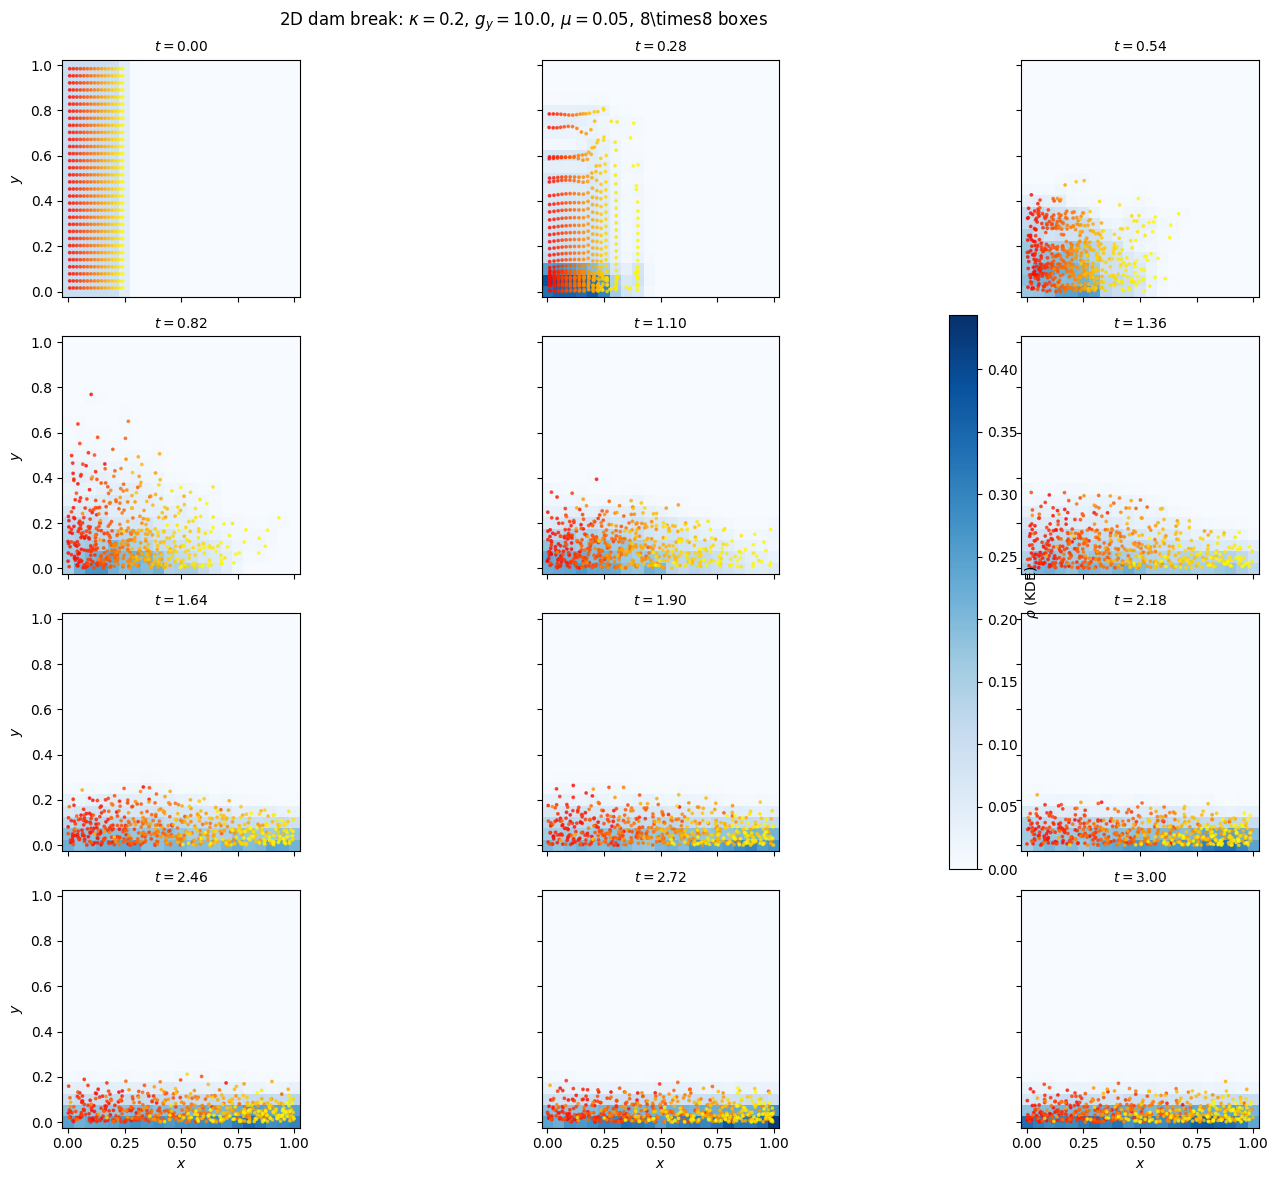

In [8]:
snapshot_inds = np.round(np.linspace(0, Nt, 12)).astype(int)
orb_inds      = np.round(np.linspace(0, Nt_orb - 1, 12)).astype(int)
vmax_plot     = float(np.max(n_arr))

fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
im = None
for ax, idx, oidx in zip(axes.flatten(), snapshot_inds, orb_inds):
    n_2d = n_arr[idx, :, :, 0]
    im = ax.pcolormesh(X, Y, n_2d, vmin=0.0, vmax=vmax_plot, cmap="Blues", shading="auto")
    ax.scatter(
        orbits[oidx, :, 0],
        orbits[oidx, :, 1],
        c=c_val, cmap="autumn", s=3,
        vmin=0.0, vmax=1.0, alpha=0.7,
    )
    ax.set_title(f"$t = {times[idx]:.2f}$", fontsize=10)
    ax.set_aspect("equal")

for ax in axes[-1, :]:
    ax.set_xlabel("$x$")
for ax in axes[:, 0]:
    ax.set_ylabel("$y$")

if im is not None:
    fig.colorbar(im, ax=axes.ravel().tolist(), label=r"$\rho$ (KDE)", shrink=0.6)

fig.suptitle(
    rf"2D dam break: $\kappa={kappa}$, $g_y={g_y}$, $\mu={mu}$, {nx}\times{nx} boxes",
    fontsize=12,
)
plt.tight_layout()
plt.show()

### Visualisation: Final Marker State

Show the final particle configuration to check that the fluid has settled into a stable layer at the bottom of the box.

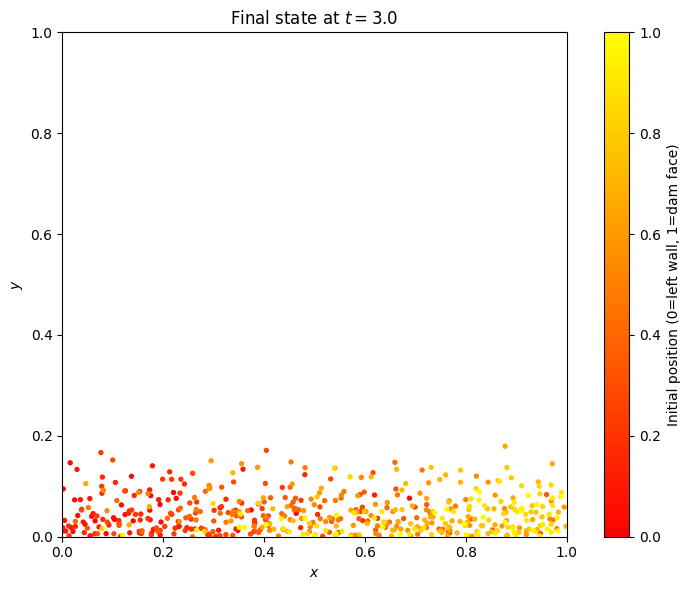

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    orbits[-1, :, 0],
    orbits[-1, :, 1],
    c=c_val, cmap="autumn", s=8, vmin=0.0, vmax=1.0,
)
ax.set_xlim(0.0, r1)
ax.set_ylim(0.0, r2)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(rf"Final state at $t = {Tend:.1f}$")
ax.set_aspect("equal")
plt.colorbar(sc, ax=ax, label="Initial position (0=left wall, 1=dam face)")
plt.tight_layout()
plt.show()

### Verification Check

Since the dam break has no simple analytical steady state, the verification is a **domain-bounds assertion**: no marker should escape the closed reflective box. A 1% tolerance accounts for the finite displacement during a single time step.

In [10]:
x_all = orbits[:, :, 0]
y_all = orbits[:, :, 1]

x_min, x_max = float(np.min(x_all)), float(np.max(x_all))
y_min, y_max = float(np.min(y_all)), float(np.max(y_all))

print("=== Dam Break Domain Bounds Verification ===")
print(f"  x range: [{x_min:.4f}, {x_max:.4f}]  (domain [0, {r1}])")
print(f"  y range: [{y_min:.4f}, {y_max:.4f}]  (domain [0, {r2}])")

tol = 0.01   # 1% of domain size

try:
    assert x_min >= -tol * r1 and x_max <= (1.0 + tol) * r1, (
        f"Markers escaped x-domain: x in [{x_min:.4f}, {x_max:.4f}]"
    )
    print("\n✓ x-domain bounds check passed.")
except AssertionError as e:
    print(f"\n✗ {e}")

try:
    assert y_min >= -tol * r2 and y_max <= (1.0 + tol) * r2, (
        f"Markers escaped y-domain: y in [{y_min:.4f}, {y_max:.4f}]"
    )
    print("✓ y-domain bounds check passed.")
except AssertionError as e:
    print(f"✗ {e}")

=== Dam Break Domain Bounds Verification ===
  x range: [0.0000, 1.0000]  (domain [0, 1.0])
  y range: [0.0000, 0.9844]  (domain [0, 1.0])

✓ x-domain bounds check passed.
✓ y-domain bounds check passed.


### Conclusion

This tutorial demonstrated the SPH method for a free-surface flow problem:

- **Weakly Compressible SPH (WCSPH)**: the isothermal equation of state with small $\kappa$ provides a pressure response that keeps the flow subsonic while allowing large density variations — the hallmark of free-surface SPH.
- **Mirror ghost particles** enforce reflective boundary conditions on all four walls without special treatment for free surfaces.
- **Reject-weights** cleanly removes near-vacuum markers before the simulation, avoiding spurious SPH interactions in the void region.
- **Marker colouring** by initial position reveals the mixing and transport patterns during the collapse and subsequent sloshing.
- The domain-bounds assertion verifies that the boundary conditions work correctly throughout the highly dynamic simulation.

The dam break is a standard benchmark for validating SPH implementations. More quantitative comparisons (run-up height, wave arrival time) can be made against published experimental data or higher-resolution SPH simulations.

In [11]:
# Optional cleanup
if False:   # set to True to remove simulation output
    shutil.rmtree(test_folder)
    print(f"Cleaned up {test_folder}")